In [94]:
# Final Exam Data Science for Business
## Ludovic DELOT BRAVO 20250306

## Q1. Importing DF, Info and Cleaning


In [95]:
# --- Data & Math ---
import pandas as pd          # pd = short alias for pandas
import numpy as np           # np = short alias for numpy

# --- Visualization ---
import matplotlib.pyplot as plt   # plt = alias for drawing charts
import seaborn as sns              # sns = alias for better-looking charts

# --- Machine Learning (sklearn = scikit-learn) ---
from sklearn.model_selection import train_test_split   # Split data into train/test
from sklearn.preprocessing import StandardScaler        # Scale numeric variables
from sklearn.preprocessing import LabelEncoder          # Convert text to numbers

# --- Models ---
from sklearn.linear_model import LogisticRegression     # Logistic Regression
from sklearn.ensemble import RandomForestClassifier     # Random Forest

# --- Metrics for model evaluation ---
from sklearn.metrics import (
    accuracy_score,           # % of correct predictions
    precision_score,          # Of all predicted positives, how many were truly positive
    recall_score,             # Of all actual positives, how many did we detect
    f1_score,                 # Balanced average of precision and recall
    roc_auc_score,            # Area under the ROC curve (0.5 = random, 1.0 = perfect)
    confusion_matrix,         # Table of hits vs errors
    classification_report     # Full per-class report
)

# --- Display settings (optional but useful) ---
pd.set_option("display.max_columns", None)              # Show all columns
pd.set_option("display.float_format", lambda x: f"{x:.3f}")  # 3 decimals

### Q1A. Importing Data

In [96]:

df = pd.read_excel('/content/Decathlon_Data-2026.xlsx')

### Q1B. Exploratory Data Analysis

In [97]:
#first rows
df.head(5)



,gender,continent,age,bought DECATHLON products,prefer to purchase,buy the most,How often do you buy,the main reason you buy DECATHLON products,How do you describe your expectations of the product?,the relationship cost/benefit of DECATHLON products?,SERVICES_1_to_5,COMMUNICATION_1_to_5,SATISFACTION_RATE(%),RECOMMANDATION_RATE(%),Loyalty_rate(%),Average Order Amount,Premium member
0,Female,America,33 or older,Yes,DECATHLON In-stores,Shoes,Occasionally - once every year,Trend / Brand,Greatly exceed expectations,Disagree,1.000,2.000,14.000,2.000,0.000,12.000,0
1,Male,America,24 to 32,Yes,NaN,Clothing,Occasionally - once every year,Price,NaN,Agree,2.000,3.000,28.000,22.000,12.000,13.000,0
2,Male,America,33 or older,Yes,DECATHLON In-stores,Clothing,NaN,Quality,Matched expectations,Disagree,3.000,4.000,42.000,40.000,35.000,13.000,0
3,Male,America,24 to 32,Yes,DECATHLON In-stores,Clothing,Occasionally - once every year,Price,Matched expectations,Disagree,2.000,2.000,14.000,18.000,16.000,14.000,0
4,Female,America,24 to 32,Yes,DECATHLON In-stores,Clothing,Occasionally - once every year,Quality,Matched expectations,Agree,5.000,5.000,63.000,40.000,41.000,14.000,1


In [98]:
#shape
df.shape

(151, 17)

In [99]:
#columns
df.columns.tolist()

['gender',
 'continent',
 ' age ',
 ' bought DECATHLON  products',
 'prefer to purchase ',
 'buy the most',
 'How often do you buy ',
 'the main reason you buy DECATHLON  products',
 'How do you describe your expectations of the product?',
 ' the relationship cost/benefit of DECATHLON  products?',
 'SERVICES_1_to_5',
 'COMMUNICATION_1_to_5',
 'SATISFACTION_RATE(%)',
 'RECOMMANDATION_RATE(%)',
 'Loyalty_rate(%)',
 ' Average Order Amount ',
 'Premium member       ']

In [100]:
#data types
df.dtypes

,0
gender,object
continent,object
age,object
bought DECATHLON products,object
prefer to purchase,object
buy the most,object
How often do you buy,object
the main reason you buy DECATHLON products,object
How do you describe your expectations of the product?,object
the relationship cost/benefit of DECATHLON products?,object


In [101]:
#summary

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 17 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   gender                                                  140 non-null    object 
 1   continent                                               144 non-null    object 
 2    age                                                    144 non-null    object 
 3    bought DECATHLON  products                             145 non-null    object 
 4   prefer to purchase                                      143 non-null    object 
 5   buy the most                                            151 non-null    object 
 6   How often do you buy                                    146 non-null    object 
 7   the main reason you buy DECATHLON  products             143 non-null    object 
 8   How do you describe your expectations of

In [103]:
#descriptive stats
df.describe()

,SERVICES_1_to_5,COMMUNICATION_1_to_5,SATISFACTION_RATE(%),RECOMMANDATION_RATE(%),Loyalty_rate(%),Average Order Amount,Premium member
count,146.000,145.000,146.000,142.000,148.000,146.000,151.000
mean,3.219,3.841,42.808,36.401,27.074,79.726,0.563
std,1.362,1.229,18.291,14.651,14.166,58.184,0.498
min,1.000,1.000,7.000,2.000,0.000,12.000,0.000
25%,2.000,3.000,28.000,22.000,12.000,35.250,0.000
50%,3.000,4.000,42.000,40.000,30.000,55.000,1.000
75%,4.000,5.000,56.000,50.000,35.000,116.000,1.000
max,5.000,6.000,77.000,66.000,66.000,249.000,1.000


In [104]:
df.describe(include="all")

,gender,continent,age,bought DECATHLON products,prefer to purchase,buy the most,How often do you buy,the main reason you buy DECATHLON products,How do you describe your expectations of the product?,the relationship cost/benefit of DECATHLON products?,SERVICES_1_to_5,COMMUNICATION_1_to_5,SATISFACTION_RATE(%),RECOMMANDATION_RATE(%),Loyalty_rate(%),Average Order Amount,Premium member
count,140,144,144,145,143,151,146,143,145,145,146.000,145.000,146.000,142.000,148.000,146.000,151.000
unique,2,3,4,2,2,4,4,6,5,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Male,Asia,19 to 23,Yes,DECATHLON In-stores,Shoes,Occasionally - once every year,Quality,Matched expectations,Agree,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,83,95,62,128,104,70,65,81,82,113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.219,3.841,42.808,36.401,27.074,79.726,0.563
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.362,1.229,18.291,14.651,14.166,58.184,0.498
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,1.000,7.000,2.000,0.000,12.000,0.000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000,3.000,28.000,22.000,12.000,35.250,0.000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000,4.000,42.000,40.000,30.000,55.000,1.000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000,5.000,56.000,50.000,35.000,116.000,1.000


In [105]:
#missing values
print(df.isnull().sum())

gender                                                    11
continent                                                  7
 age                                                       7
 bought DECATHLON  products                                6
prefer to purchase                                         8
buy the most                                               0
How often do you buy                                       5
the main reason you buy DECATHLON  products                8
How do you describe your expectations of the product?      6
 the relationship cost/benefit of DECATHLON  products?     6
SERVICES_1_to_5                                            5
COMMUNICATION_1_to_5                                       6
SATISFACTION_RATE(%)                                       5
RECOMMANDATION_RATE(%)                                     9
Loyalty_rate(%)                                            3
 Average Order Amount                                      5
Premium member          

### Q1C Clean DF

In [106]:
# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

GROUP_COL = 'gender'

# --- B1. Numeric: mean by group ---
numeric_cols = df.select_dtypes(include='number').columns.tolist()
for col in numeric_cols:
    df[col] = df.groupby(GROUP_COL)[col].transform(
        lambda x: x.fillna(x.mean())
    )
    # transform() applies the operation WITHIN each group
    # and returns the result with the same original index

# --- B2. Categorical: mode by group ---
cat_cols = df.select_dtypes(include='object').columns.tolist()
if GROUP_COL in cat_cols:
    cat_cols.remove(GROUP_COL)  # Don't fill the group column itself

for col in cat_cols:
    df[col] = df.groupby(GROUP_COL)[col].transform(
        lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x)
    )

print("Missing values after group-based cleaning:")
print(df.isnull().sum())

Missing values after group-based cleaning:
gender                                                   11
continent                                                11
age                                                      11
bought DECATHLON  products                               11
prefer to purchase                                       11
buy the most                                             11
How often do you buy                                     11
the main reason you buy DECATHLON  products              11
How do you describe your expectations of the product?    11
the relationship cost/benefit of DECATHLON  products?    11
SERVICES_1_to_5                                          11
COMMUNICATION_1_to_5                                     11
SATISFACTION_RATE(%)                                     11
RECOMMANDATION_RATE(%)                                   11
Loyalty_rate(%)                                          11
Average Order Amount                                     

In [107]:
df[df['gender'].isnull()]

,gender,continent,age,bought DECATHLON products,prefer to purchase,buy the most,How often do you buy,the main reason you buy DECATHLON products,How do you describe your expectations of the product?,the relationship cost/benefit of DECATHLON products?,SERVICES_1_to_5,COMMUNICATION_1_to_5,SATISFACTION_RATE(%),RECOMMANDATION_RATE(%),Loyalty_rate(%),Average Order Amount,Premium member
43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
128,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
131,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
132,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
133,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


as the rows with null gender have not any data i'll remove this rows to not affect my model and this represents no loss of information

In [108]:
df.dropna(subset=['gender'], inplace=True)
print(f"Shape after dropping null gender rows: {df.shape}")

Shape after dropping null gender rows: (140, 17)


## Q2. Data Manipulation and Visulization

## Q2.1 Data Manipulation

In [109]:
### Q2.1A print the minimum of SR and RR by continent and prefer to purchase

In [110]:
min_rates = df.groupby(['continent', 'prefer to purchase'])[['SATISFACTION_RATE(%)', 'RECOMMANDATION_RATE(%)']].min()
print(min_rates)

                                SATISFACTION_RATE(%)  RECOMMANDATION_RATE(%)
continent prefer to purchase                                                
America   DECATHLON  In-stores                14.000                   2.000
          Online                              28.000                  18.000
Asia      DECATHLON  In-stores                 7.000                   2.000
          Online                               7.000                  18.000
Europe    DECATHLON  In-stores                12.000                   2.000
          Online                              28.000                  40.000


In [111]:
### Q2.1B Highest SR for each buy the most category by continent

In [112]:
result = df.loc[df.groupby(['continent', 'buy the most'])['SATISFACTION_RATE(%)'].idxmax()]

# Sort by continent for better readability
result = result.sort_values(by=['continent', 'buy the most'])

print("Product with the highest satisfaction rate for each 'buy the most' category by continent:")
for index, row in result.iterrows():
    print(f"Continent: {row['continent']}, Product: {row['buy the most']}, Max Satisfaction Rate: {row['SATISFACTION_RATE(%)']:.2f}")

Product with the highest satisfaction rate for each 'buy the most' category by continent:
Continent: America, Product: Accesories, Max Satisfaction Rate: 42.00
Continent: America, Product: Clothing, Max Satisfaction Rate: 63.00
Continent: America, Product: Shoes, Max Satisfaction Rate: 56.00
Continent: Asia, Product: Accesories, Max Satisfaction Rate: 77.00
Continent: Asia, Product: Clothing, Max Satisfaction Rate: 63.00
Continent: Asia, Product: Shoes, Max Satisfaction Rate: 65.00
Continent: Asia, Product: Underwear, Max Satisfaction Rate: 56.00
Continent: Europe, Product: Accesories, Max Satisfaction Rate: 63.00
Continent: Europe, Product: Clothing, Max Satisfaction Rate: 63.00
Continent: Europe, Product: Shoes, Max Satisfaction Rate: 66.00
Continent: Europe, Product: Underwear, Max Satisfaction Rate: 42.00


In [113]:
### Q2.1C Max average order amount

In [114]:
max_order_amount_row = df.loc[df['Average Order Amount'].idxmax()]

gender_max_amount = max_order_amount_row['gender']
continent_max_amount = max_order_amount_row['continent']
age_max_amount = max_order_amount_row['age']

print(f"Gender: {gender_max_amount}, Continent: {continent_max_amount}, Age: {age_max_amount}")

Gender: Male, Continent: Asia, Age: 33 or older


In [115]:
### Q2.1D Europe Continent Analysis Loyalty Rate

In [116]:
min_loyalty_rate = df['Loyalty_rate(%)'].min()
max_loyalty_rate = df['Loyalty_rate(%)'].max()

print(f"Minimum Loyalty Rate: {min_loyalty_rate:.2f}")
print(f"Maximum Loyalty Rate: {max_loyalty_rate:.2f}")

Minimum Loyalty Rate: 0.00
Maximum Loyalty Rate: 66.00


i did this to see how the value was composed and if i need to filter for higher than .4 or 40

In [117]:
europe_loyal_customers = df[(df['continent'] == 'Europe') & (df['Loyalty_rate(%)'] > 40)]

selected_columns = [
    'gender',
    'buy the most',
    'How often do you buy',
    'the main reason you buy DECATHLON  products' # Corrected column name
]

print("Customers from Europe with Loyalty Rate > 40:")
display(europe_loyal_customers[selected_columns])

Customers from Europe with Loyalty Rate > 40:


,gender,buy the most,How often do you buy,the main reason you buy DECATHLON products
73,Male,Clothing,Frequently - every 2-3 months,Quality
78,Female,Shoes,Frequently - every 2-3 months,Quality
83,Female,Accesories,Rarely - every couple of years or more,Trend / Brand
114,Male,Accesories,Frequently - every 2-3 months,Quality
115,Male,Accesories,Rarely - every couple of years or more,Quality
130,Female,Shoes,Frequently - every 2-3 months,Trend / Brand
138,Female,Shoes,Occasionally - once every year,Quality
143,Female,Shoes,Occasionally - once every year,Quality


## Q2.2 Data Visualization

### Q2.2A Maximum Average Order Amount by Continent

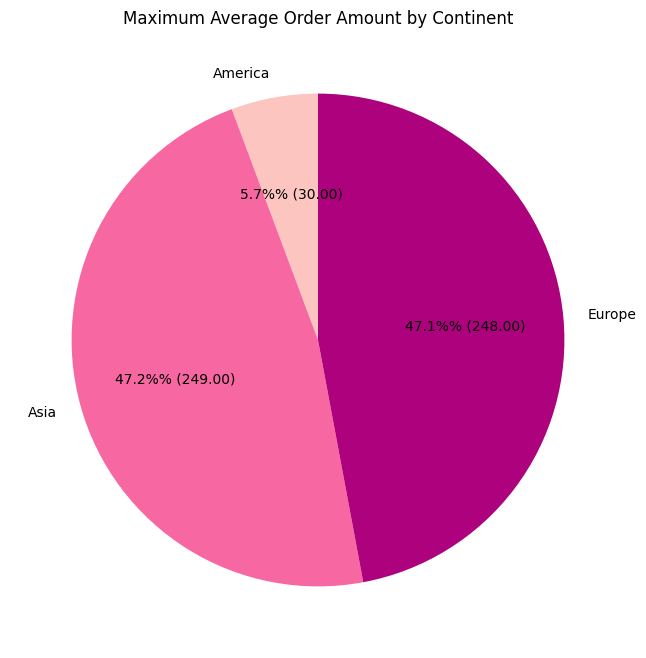

In [131]:
max_avg_order_by_continent = df.groupby('continent')['Average Order Amount'].max()

plt.figure(figsize=(8, 8))
colors = sns.color_palette("RdPu", len(max_avg_order_by_continent)) # Using a Red-Purple colormap for magenta tones

def autopct_format(pct):
    total = sum(max_avg_order_by_continent)
    val = pct/100.*total
    return f'{pct:.1f}%% ({val:.2f})'

plt.pie(max_avg_order_by_continent, labels=max_avg_order_by_continent.index, autopct=autopct_format, startangle=90, colors=colors)
plt.title('Maximum Average Order Amount by Continent')
plt.ylabel('') # Hide the default y-label
plt.show()

As observed in the pie chart, Asia has the highest maximum average order amount at 249.00, followed closely by Europe with 248.00, and America with 30.00.

In [119]:
### Q2.2B Buying Frequency Analysis

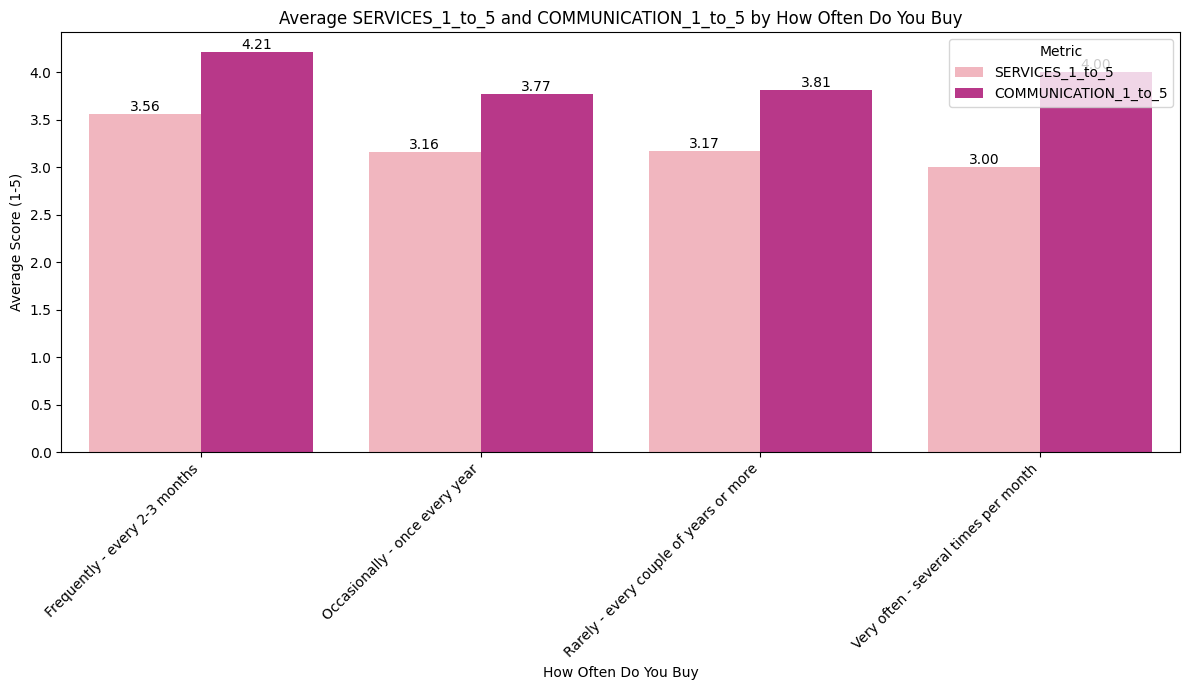

In [132]:
avg_services_communication = df.groupby('How often do you buy')[['SERVICES_1_to_5', 'COMMUNICATION_1_to_5']].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(data=avg_services_communication.melt(id_vars='How often do you buy', var_name='Metric', value_name='Average Score'),
            x='How often do you buy', y='Average Score', hue='Metric', palette='RdPu')
plt.title('Average SERVICES_1_to_5 and COMMUNICATION_1_to_5 by How Often Do You Buy')
plt.xlabel('How Often Do You Buy')
plt.ylabel('Average Score (1-5)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')

# Add values on top of each bar
ax = plt.gca() # Get current axes
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

here it appears that customers who buy very often - several times per month show the highest average scores for both services and communication, suggesting a strong engagement with Decathlon's offerings.

### Q2.2C Maximum Loyalty Rate and Recommendation Rate by Continent

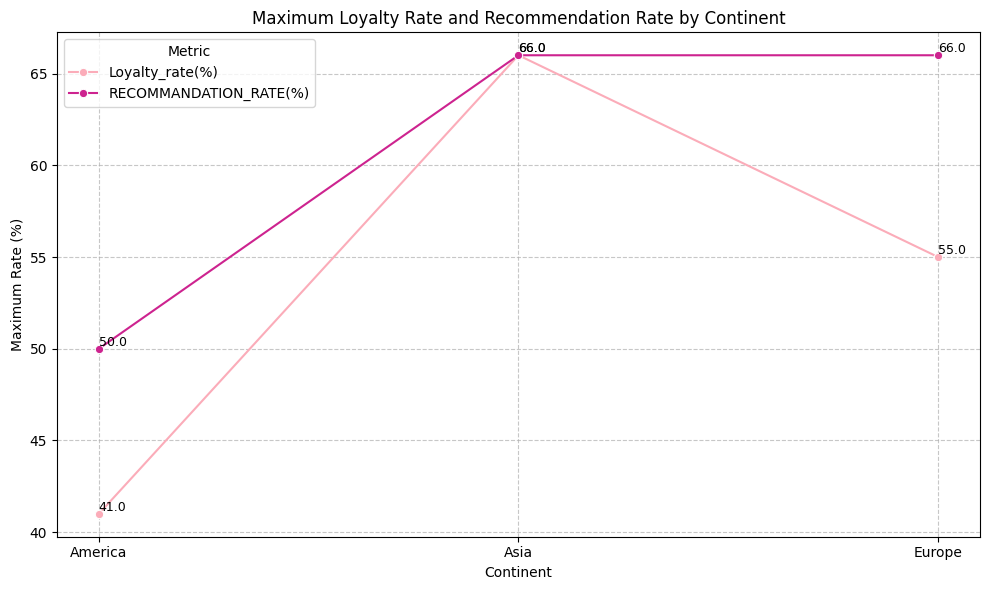

In [133]:
max_rates_by_continent = df.groupby('continent')[['Loyalty_rate(%)', 'RECOMMANDATION_RATE(%)']].max().reset_index()

plt.figure(figsize=(10, 6))
ax = sns.lineplot(data=max_rates_by_continent.melt(id_vars='continent', var_name='Metric', value_name='Rate'),
             x='continent', y='Rate', hue='Metric', marker='o', palette='RdPu')
plt.title('Maximum Loyalty Rate and Recommendation Rate by Continent')
plt.xlabel('Continent')
plt.ylabel('Maximum Rate (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Metric')

# Add data labels
for line in ax.lines:
    for x_val, y_val in zip(line.get_xdata(), line.get_ydata()):
        ax.text(x_val, y_val, f'{y_val:.1f}', color='black', ha='left', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

we can observe that Asia leads in both maximum loyalty and recommendation rates (both at 66%) and Europe follows closely with a maximum recommendation rate of 66% and a loyalty rate of 55% and America shows the lowest maximum loyalty rate at 41% but a respectable recommendation rate of 50%.

In [122]:
### Q2.2D Average Order Amount

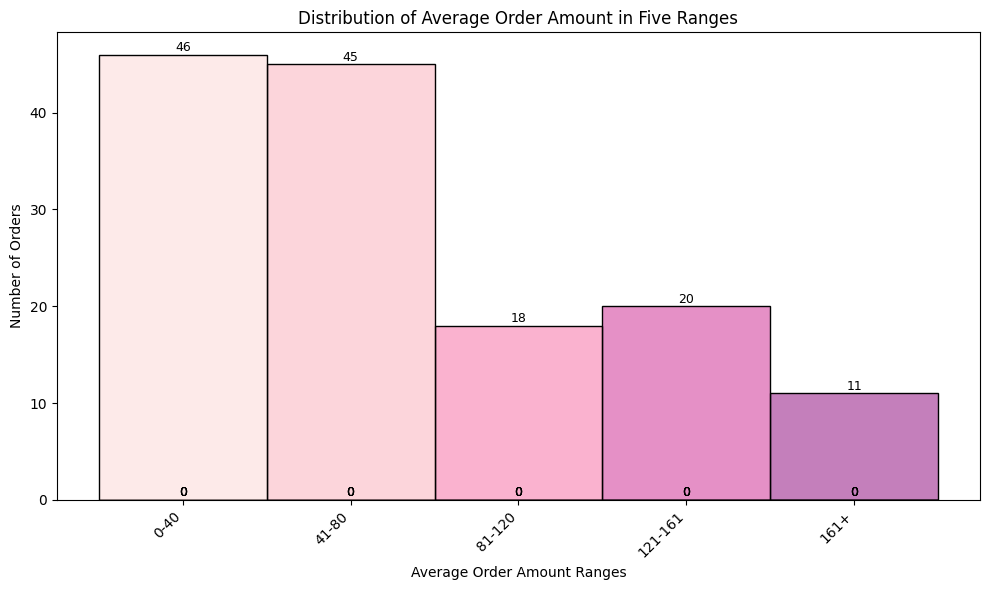

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the bins for the histogram
bins = [0, 40, 80, 120, 161, df['Average Order Amount'].max() + 1]

# Define labels for the bins
labels = ['0-40', '41-80', '81-120', '121-161', '161+']

# Create a new column with the binned data
df['Average Order Amount Bins'] = pd.cut(df['Average Order Amount'], bins=bins, labels=labels, right=False)

plt.figure(figsize=(10, 6))
ax = sns.histplot(data=df, x='Average Order Amount Bins', palette='RdPu', hue='Average Order Amount Bins', legend=False)
plt.title('Distribution of Average Order Amount in Five Ranges')
plt.xlabel('Average Order Amount Ranges')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')

# Add data labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=9, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

and analyzing the distribution of the Average Order Amount, a significant concentration is observed in the first bin (0-40), so a large portion of transactions are of low amounts and i think that the current distribution of bins could be improved to capture more detail, especially in the initial ranges

## Q3. Coding Challenge

In [124]:
import re

def accepted_product(df_input):
    """
    Filters Decathlon products based on specific criteria to identify products
    that can benefit from a sales period.

    Args:
        df_input (pd.DataFrame): The input DataFrame containing product data.

    Returns:
        pd.DataFrame: A DataFrame listing unique 'buy the most' products by 'continent'
                      that meet all acceptance conditions.
    """
    df = df_input.copy()

    # Calculate Sales_Index, handling potential division by zero by replacing 0 with NaN
    # Based on df.describe(), RECOMMANDATION_RATE(%) min is 2.0, so no explicit division by zero handling needed for current data.
    df['Sales_Index'] = df['SATISFACTION_RATE(%)'] / df['RECOMMANDATION_RATE(%)']

    # Calculate Service_Index
    # Based on df.describe(), COMMUNICATION_1_to_5 min is 1.0, so no explicit division by zero handling needed for current data.
    df['Service_Index'] = df['SERVICES_1_to_5'] / df['COMMUNICATION_1_to_5']

    # Condition 1: Product sales index value is greater than Average of (Sales-Index)
    # Calculate average sales index considering only non-NaN values
    average_sales_index = df['Sales_Index'].mean()
    condition1 = df['Sales_Index'] > average_sales_index

    # Condition 2: The product Service index value is bigger than (0.70)
    condition2 = df['Service_Index'] > 0.70

    # Condition 3: The relationship cost/benefit of DECATHLON products? equal = 'Agree'
    # Ensure column values are stripped of whitespace for accurate comparison
    # The column name originally had extra spaces which df.columns.str.strip() in an earlier cell fixed for leading/trailing,
    # but not internal double spaces. The correct column name in the DataFrame is 'the relationship cost/benefit of DECATHLON  products?'
    df['the relationship cost/benefit of DECATHLON  products?'] = df['the relationship cost/benefit of DECATHLON  products?'].str.strip()
    condition3 = df['the relationship cost/benefit of DECATHLON  products?'] == 'Agree'

    # Condition 4: The prefer to purchase equal = 'DECATHLON In-stores'
    # Ensure column values are stripped of whitespace for accurate comparison
    df['prefer to purchase'] = df['prefer to purchase'].str.strip()
    condition4 = df['prefer to purchase'] == 'DECATHLON In-stores'

    # Combine all conditions to filter the DataFrame
    accepted_products_df = df[condition1 & condition2 & condition3 & condition4]

    # Return the List of Products 'buy the most' by 'continent' as unique combinations
    result = accepted_products_df[['continent', 'buy the most']].drop_duplicates().reset_index(drop=True)

    return result

## Q4 Machine Learning Model

### Q4A. Data Preparation for Machine Learning

In [125]:
# 1. Data Preparation for Machine Learning

# Drop the 'Average Order Amount Bins' column if it exists, as it's a derived visualization column.
if 'Average Order Amount Bins' in df.columns:
    df = df.drop(columns=['Average Order Amount Bins'])

# Re-check for any remaining missing values after previous cleaning steps.
# If there are any, we'll fill them before encoding.
print("Missing values before ML preprocessing:")
print(df.isnull().sum())

# For any remaining numeric NaNs, impute with the mean. For categorical NaNs, impute with the mode.
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].mean())

print("\nMissing values after final imputation:")
print(df.isnull().sum())

# Define features (X) and target (y)
X = df.drop('Premium member', axis=1)
y = df['Premium member']

# Identify categorical and numerical columns for preprocessing
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(include=np.number).columns

# One-hot encode categorical features
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Ensure all column names are valid for scikit-learn (e.g., remove special characters or long names if any)
X.columns = [col.replace('[', '').replace(']', '').replace('<', '').replace(' ', '_').replace('(', '').replace(')', '').replace('%', 'pct').replace('/', '_').replace('-', '_') for col in X.columns]


Missing values before ML preprocessing:
gender                                                   0
continent                                                0
age                                                      0
bought DECATHLON  products                               0
prefer to purchase                                       0
buy the most                                             0
How often do you buy                                     0
the main reason you buy DECATHLON  products              0
How do you describe your expectations of the product?    0
the relationship cost/benefit of DECATHLON  products?    0
SERVICES_1_to_5                                          0
COMMUNICATION_1_to_5                                     0
SATISFACTION_RATE(%)                                     0
RECOMMANDATION_RATE(%)                                   0
Loyalty_rate(%)                                          0
Average Order Amount                                     0
Premium member  

### Q4B Split of Data

In [126]:
# 2. Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

### Q4C Build and Train the Random Forest Model

In [126]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') # Using class_weight to handle potential imbalance
rf_model.fit(X_train, y_train)

### Q4D Make Predictions

In [127]:
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1] # Probability of being a Premium member

### Q4E Model Evaluation


--- Random Forest Model Evaluation ---
Accuracy: 0.8571
Precision: 0.8462
Recall: 0.9167
F1-Score: 0.8800
ROC AUC Score: 0.9074

Confusion Matrix:
[[14  4]
 [ 2 22]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.78      0.82        18
         1.0       0.85      0.92      0.88        24

    accuracy                           0.86        42
   macro avg       0.86      0.85      0.85        42
weighted avg       0.86      0.86      0.86        42


Top 10 Feature Importances:
Average_Order_Amount                                                         0.176
SATISFACTION_RATEpct                                                         0.160
SERVICES_1_to_5                                                              0.138
COMMUNICATION_1_to_5                                                         0.094
RECOMMANDATION_RATEpct                                                       0.083
Loyalty_ratepct                       

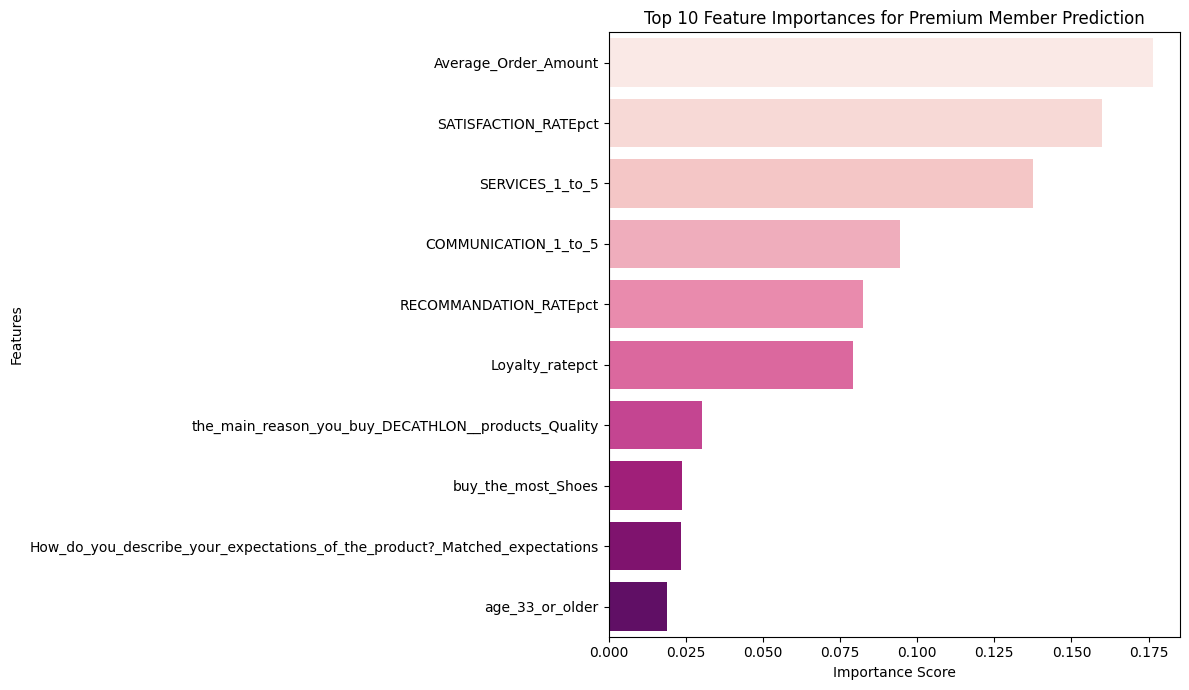

In [128]:
# 5. Evaluate the Model
print("\n--- Random Forest Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance (Optional but good for interpretation)
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 10 Feature Importances:")
print(feature_importances.head(10))

# Plotting feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x=feature_importances.head(10).values, y=feature_importances.head(10).index, palette='RdPu', hue=feature_importances.head(10).index, legend=False)
plt.title('Top 10 Feature Importances for Premium Member Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

The Random Forest model achieved an 86% accuracy and it showed strong predictive power for premium members with an F1-score of 0.88, while also performing well for non-premium members with an F1-score of 0.82

Also I think that it is a very good model since the dataset is not that large with very good scores so we can say that is not overfitted and not underperforming

so for this model we have a balanced performance for the premium and not premium users so this is a very good indicator of a robust model

I believe the Random Forest model I developed performed very well and achieving quite high accuracy and a strong ROC AUC score

also i was particularly interested in the significance of variables like Average Order Amount, SATISFACTION_RATE(%), and SERVICES_1_to_5 but i think however this makes perfect sense, as intuitively, these factors are crucial for understanding and predicting whether a customer will become a Premium member and i think that will be very iuseful for the data science team in Decathlon in order to be more smart in decision making